<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/LED/Lab4_PE_RCA929_LEDs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect



# Resume

**Method.** For each LED we recorded the current–voltage curve of the RCA929 phototube. In the strong retarding region ($V < -2\,\text{V}$) the cathode is fully stopped, so the current there is only the anode (back) current plus dark current; we fitted it with a straight line and subtracted it. What is left is the cathode current. Following Du Bridge, we take its square root, fit a straight line to the linear part, and read $V_0$ as the point where that line crosses zero. Plotting $V_0$ against light frequency gives a slope of $h/e$. With all axes in electron‑volts the expected slope is 1. The 730 nm LED gave no usable signal and was dropped. The approach follows [Hall1971](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/Hall1971_Photoelectric%20Effect%20and%20Planck's%20Constant%20in%20the%20Introductory%20lab.pdf).

**The slope.** Using the *nominal* LED wavelengths the slope is **0.84** of the expected value. But each LED emits a band, not a single line (see the [spectrum notebook](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/LED/lab4_pe_led_spectrum.ipynb)). Since $V_0$ is set by the most energetic photons, we re‑plotted against the measured short-wavelength (high-energy) edge of each band. This raises the slope to **0.93**. The correction is largest for the broad green/yellow LEDs, whose high-energy edge is well above their nominal value — this is the main reason the nominal slope was low. Using the observed band edge clearly improves the result. [Garver (2006)](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/Garver2006_The%20Photoelectric%20Effect%20Using%20LEDs%20as%20Light%20Sources%20(1).pdf) reports a similar value (0.93), but from nominal wavelengths; our nominal slope (0.84) is lower, and only the band-edge correction brings us to his level. The result is good enough for an introductory experiment, but not for an accurate measurement of $h/e$.

**The offset.** Here the contact potential between cathode and anode matters. As shown by Melissinos,  the intercept of the line gives the work function of the **anode (collector)**, not of the photocathode. So our offset (about **1.7 V** with the band‑edge fit) is an estimate of the **anode** work function $\phi_A$, which is not known in advance. It should not be compared with the 2.05 eV work function of the Cs-Sb cathode. The two values happen to be close only because the anode is also coated with cesium during manufacture, which lowers its work function into the same range. In short: this experiment measures $h/e$ from the slope, but it does not measure the photocathode work function.

**Main factor of uncertainties** The stopping voltage $V_0$ has no unique definition. The band edges read by eye are themselves uncertain (the deep‑blue edge of the 395 nm LED is probably underestimated because the eye barely sees it).



In [33]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.constants import h, elementary_charge as e, speed_of_light as c
from urllib import request
!wget -q https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab4_SP/spectrumplots.py -O spectrumplots.py -q
from spectrumplots import wavelength_to_color

## Auxillary functions

In [61]:
def find_root2(V, I, *,
              noise_k=10.0,
              r2_min=0.995,
              min_points=5,
              trim_right=0,
              return_diagnostics=False):
    """
    Stopping voltage V0 by the Du Bridge method, fitting the LINEAR segment
    of sqrt(cathode current) and extrapolating to zero.

    Strategy (grows the window from V=0 leftward):
      1. baseline = anode + dark + leakage, fitted where cathode is off
         (V <= anode_Vmax) and subtracted -> R = cathode current.
      2. On the retarding side (V<0, cathode on), walk from the point
         nearest V=0 toward more negative V, adding points one at a time.
         Keep the LONGEST window whose linear fit of sqrt(R) vs V still has
         R^2 >= r2_min. This stops automatically when the thermal foot
         (left bend) starts to spoil the straight line.
      3. Optionally drop `trim_right` points nearest V=0 first, to discard
         the saturation / space-charge bend at the right end.
      4. V0 = x-intercept of that linear segment (foot is never used).

    No spectrum and no Fowler-DuBridge model required -- one rule:
    "fit the line where it is straight, extrapolate to zero."

    Parameters
    ----------
    noise_k    : cathode counts as "on" when R > noise_k * baseline scatter.
    r2_min     : linearity threshold for growing the window.
    min_points : smallest acceptable linear segment.
    trim_right : how many points nearest V=0 to skip (saturation bend).
    """
    V = np.asarray(V, float); I = np.asarray(I, float)
    order = np.argsort(V); V, I = V[order], I[order]

    base = V <= ANODE_VMAX
    if base.sum() < 3:
        return (np.nan, {"reason": "no baseline region; extend sweep"}) \
            if return_diagnostics else np.nan
    lr = linregress(V[base], I[base])
    R = I - (lr.slope * V + lr.intercept)
    noise = np.std(R[base])

    on = (R > noise_k * noise) & (V < NORMPOINT) & (V > ANODE_VMAX)
    if on.sum() < min_points + trim_right:
        return (np.nan, {"reason": "too few cathode points", "baseline": lr}) \
            if return_diagnostics else np.nan

    xv = V[on]; yv = np.sqrt(R[on])
    # sort from V=0 (right) toward negative (left)
    idx = np.argsort(xv)[::-1]
    xs, ys = xv[idx], yv[idx]
    if trim_right:
        xs, ys = xs[trim_right:], ys[trim_right:]

    # grow window from the right; keep the longest with R^2 >= r2_min
    best_n, best_fit = 0, None
    for n in range(min_points, len(xs) + 1):
        f = linregress(xs[:n], ys[:n])
        if f.rvalue**2 >= r2_min:
            best_n, best_fit = n, f
        # once it has been good and then drops, we can stop early
        elif best_n >= min_points and f.rvalue**2 < r2_min:
            break
    if best_fit is None:                       # never linear enough -> longest run
        best_n = len(xs); best_fit = linregress(xs, ys)

    V0 = -best_fit.intercept / best_fit.slope
    if return_diagnostics:
        seg = idx[trim_right: trim_right + best_n]
        return V0, {"anode_fit": lr, "noise": noise, "cathode_current": R,
                    "cathode_mask": on, "fit_x": xs[:best_n], "fit_y": ys[:best_n],
                    "cathode_fit": best_fit, "r2": best_fit.rvalue**2, "best_n": best_n,
                    "xv": xv, "yv":yv}
    return V0


def get_observed_by_nominal(wl_nominal):
  d = 1e-3 / 500 # 500 lines per mm
  data = '''
  # band_nominal(from..to)[nm] thetas1(from..to)[deg] thetas2(from .. to)[deg]
  500 510 13.88 16.01 13.71 16.39
  390 395 11.38 12.41 11.40 12.57 # and weak green-red band 14.2 18.6
  730 730 19.2 21.56 18.56 21.9
  540 550 14.76 17.75 14.92 17.44
  560 570 15.25 18.50 15.46 18.07
  520 525 14.20 17.60 14.50 17.40
  420 425 11.5 12.6 11.6 12.70
  400 410 11.45 12.51 11.44 12.40
  '''
  #if wl_nominal ==730:
  #  return 730, 10
  wl_nominal1, wl_nominal2, thetaleft1, thetaright1, thetaleft2, thetaright2 = np.genfromtxt(data.splitlines()).T
  thetaleft = (thetaleft1 + thetaleft2) / 2
  thetaright = (thetaright1 + thetaright2) / 2
  wl_blue = d * np.sin(np.deg2rad(thetaleft))*1e9
  wl_red = d * np.sin(np.deg2rad(thetaright))*1e9
  mask = (wl_nominal1 <= wl_nominal) & (wl_nominal <= wl_nominal2)
  return wl_blue[mask][0], wl_red[mask][0]

get_observed_by_nominal(395)

(np.float64(394.97249554781183), np.float64(432.538429688842))

#Volt-ampere curve


(0.0, 0.0028866566514134154)

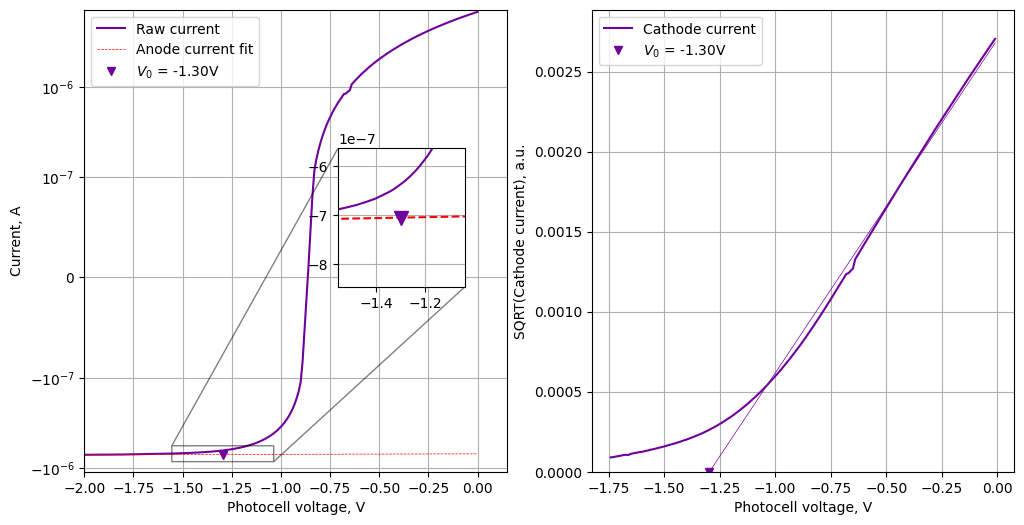

In [41]:
URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/LED/'
NORMPOINT = 0 #V
ANODE_VMAX = -2.0 #V

# example
fig, ax = plt.subplots(1, 2, figsize=(12,6))
name, wl = 'RCA929', 400

color = wavelength_to_color(wl)
url = URL+ f'{name}.csv'
text = request.urlopen(url).read().decode('utf-8').splitlines()
V, I, WL  = np.genfromtxt(text, \
                              delimiter=',', usecols=[1,3,7], skip_header=1, unpack=True)
wls = np.unique(WL)
mask = (WL == wl)
Vm = V[mask]
Im = I[mask]
V0, debug = find_root2(Vm, Im, return_diagnostics=True)
anode_fit = debug['anode_fit']
ax[0].plot(Vm, Im, color=color, label='Raw current')
ax[0].plot(Vm, anode_fit.slope * Vm + anode_fit.intercept, color='red', lw=0.5, ls='--', label='Anode current fit')
ax[0].plot(V0, anode_fit.slope * V0 + anode_fit.intercept, 'v', color=color, label=rf'$V_0$ = {V0:.2f}V')
ax[0].set_xlabel('Photocell voltage, V')
ax[0].set_ylabel('Current, A')
ax[0].grid()
ax[0].set_xlim(left=-2)
ax[0].set_yscale('symlog', linthresh=1e-7)
ax[0].legend()

axins = ax[0].inset_axes([0.6, 0.4, 0.3, 0.3]) # [x, y, width, height] in axes coordinates
axins.plot(Vm, Im, color=color)
axins.plot(Vm, anode_fit.slope * Vm + anode_fit.intercept, color='red', ls='--')
I0 = anode_fit.slope * V0 + anode_fit.intercept
axins.plot(V0, anode_fit.slope * V0 + anode_fit.intercept, 'v', color=color, ms=10)

axins.set_xlim(V0*1.2, V0*0.8)
axins.set_ylim(I0*1.2,I0*0.8)
axins.grid(True)
ax[0].indicate_inset_zoom(axins, edgecolor="black")

#
on = debug['cathode_mask']
xv, yv, cathode_fit = debug['xv'], debug['yv'], debug['cathode_fit']
ax[1].plot(xv, yv, '-', color=color, label='Cathode current')
ax[1].plot(V0, 0, 'v', color=color, label=rf'$V_0$ = {V0:.2f}V')
ax[1].plot(xv, cathode_fit.slope * xv + cathode_fit.intercept, color=color, lw=0.5)
ax[1].set_xlabel('Photocell voltage, V')
ax[1].set_ylabel('SQRT(Cathode current), a.u.')
ax[1].grid()
ax[1].legend()
ax[1].set_ylim(bottom=0)


<>:68: SyntaxWarning: invalid escape sequence '\s'
<>:68: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5908/546524693.py:68: SyntaxWarning: invalid escape sequence '\s'
  ax[2].set_ylabel('Du Bridge, $\sqrt{I}$ a.u.')


0 390.0
1 400.0
2 420.0
3 500.0


/tmp/ipykernel_5908/546524693.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


4 520.0
5 540.0
6 560.0
7 730.0
# wavelength(nm) V0(V) blue_edge(nm) red_edge(nm)
390 1.33 395 433
400 1.30 397 431
420 1.18 400 438
500 0.79 477 558
520 0.68 496 601
540 0.61 512 605
560 0.54 530 627
730 0.73 647 740



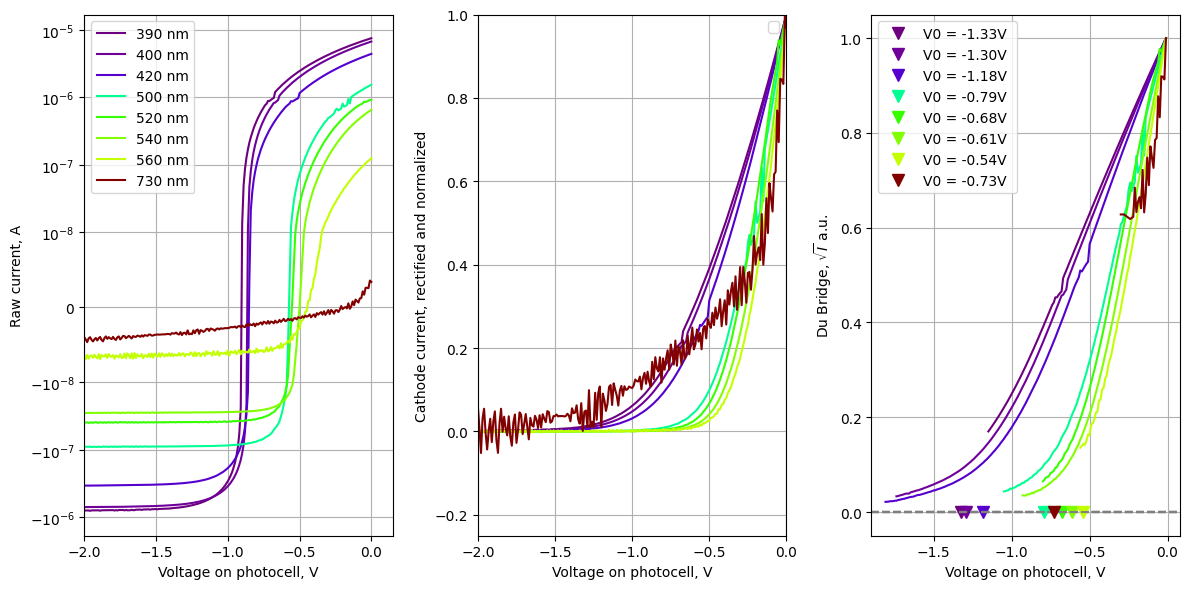

In [64]:
fig, ax = plt.subplots(1, 3, figsize=(12,6))
plt.grid()

data = '# wavelength(nm) V0(V) blue_edge(nm) red_edge(nm)\n'

name = 'RCA929'

url = URL+ f'{name}.csv'
text = request.urlopen(url).read().decode('utf-8').splitlines()
V, I, WL  = np.genfromtxt(text, \
                              delimiter=',', usecols=[1,3,7], skip_header=1, unpack=True)

for i, wl in enumerate(np.unique(WL)):
  print(i, wl)
  color= wavelength_to_color(wl)
  opacity = 1
  mask = WL==wl
  Im = I[mask]
  Vm = V[mask]

  # (1) Raw VAC

  ax[0].plot(Vm, Im, '-',  color=color, label=f'{wl:.0f} nm')
  ax[0].set_xlabel('Voltage on photocell, V');
  ax[0].set_ylabel('Raw current, A')
  ax[0].set_yscale('symlog', linthresh=1e-8)
  ax[0].set_xlim(left=-2)
  ax[0].legend()
  ax[0].grid(True)

  # (2) остаток = катодный ток
  # Find points where current I crosses zero current line
  V0, d = find_root2(Vm, Im,  return_diagnostics=True)
  if np.isnan(V0):
    print(name, d['reason'])
    continue
  # diagnostics
  R = d['cathode_current']
  on = d['cathode_mask']
  xv, yv = d['xv'], d['yv']
  cathode_fit = d['cathode_fit']

  # fill data
  wl_blue, wl_red = get_observed_by_nominal(wl)
  data += f'{wl:.0f} {-V0:.2f} {wl_blue:.0f} {wl_red:.0f}\n'

  normalization_parameter = np.max(R[Vm <= NORMPOINT])
  Im /= normalization_parameter
  R /= normalization_parameter
  ax[1].plot(Vm, R, '-', ms=2, color=color)
  #ax[1].plot(V0, 0, 'v', ms=8, color=color, label=f'V0 = {V0:.2f}V ')
  #ax[1].axvline(V0, color='#e08000', ls='--', label=f'V0 = {V0:.2f} В')
  ax[1].set_xlim(-2, 0.);
  ax[1].set_ylim(-0.25, 1)
  ax[1].set_xlabel('Voltage on photocell, V');
  ax[1].set_ylabel('Cathode current, rectified and normalized')
  ax[1].grid(True)
  ax[1].legend()

  # (3) Дю-Бридж: sqrt(R) vs V
  xv, yv = d['xv'], d['yv'];
  normalization_parameter = np.max(yv)
  yv /= normalization_parameter
  ax[2].axhline(0, color='gray', ls='--')
  ax[2].plot(V0, 0, 'v', ms=8, color=color, label=f'V0 = {V0:.2f}V ')
  ax[2].plot(xv, yv, '-', ms=2, color=color)
  ax[2].set_xlabel('Voltage on photocell, V');
  ax[2].set_ylabel('Du Bridge, $\sqrt{I}$ a.u.')
  ax[2].grid(True)
  ax[2].legend()
plt.tight_layout()

print(data)

In [65]:
data.splitlines()

['# wavelength(nm) V0(V) blue_edge(nm) red_edge(nm)',
 '390 1.33 395 433',
 '400 1.30 397 431',
 '420 1.18 400 438',
 '500 0.79 477 558',
 '520 0.68 496 601',
 '540 0.61 512 605',
 '560 0.54 530 627',
 '730 0.73 647 740']

# Plank's constant and Work potential determination

$$
 e V_0(\nu) = h \nu -  e W
$$

/tmp/ipykernel_5908/1609767320.py:6: RuntimeWarning: divide by zero encountered in divide
  return c * h/ e / energy  * 1e9


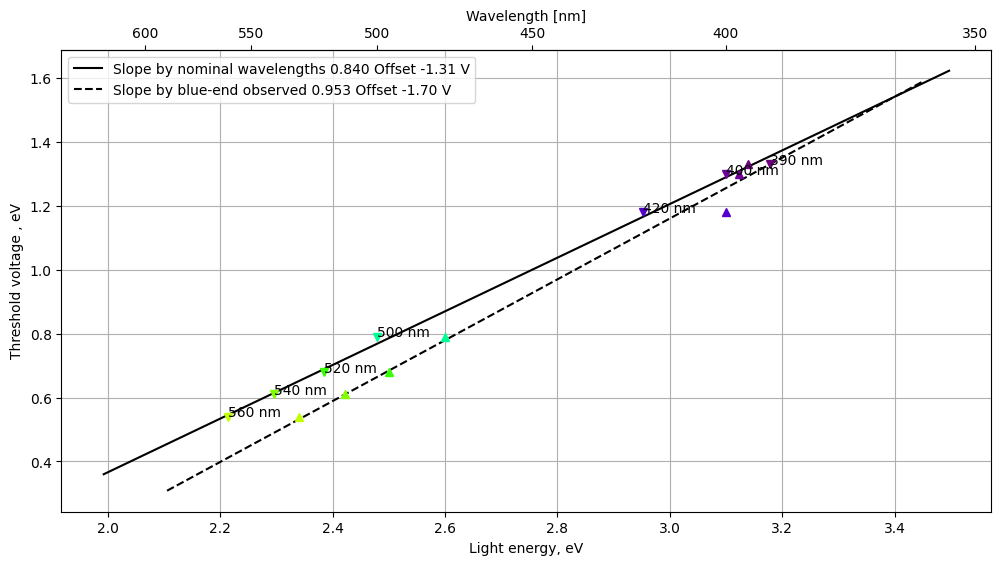

In [68]:
def wl2E(wl):
    return c * h / e / (wl *1e-9)


def E2wl(energy):
    return c * h/ e / energy  * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(wl2E, E2wl))
secax.set_xlabel('Wavelength [nm]')


wl_nominal, V0, wl_observed_blue, wl_observed_red = np.genfromtxt(data.splitlines()).T
mask = wl_nominal != 730 # skipping red with bad data
wl_nominal = wl_nominal[mask]
V0 = V0[mask]
wl_observed_blue = wl_observed_blue[mask]
wl_observed_red = wl_observed_red[mask]

energy_observed_blue = h * c / wl_observed_blue * 1e9 / e
energy_observed_red = h * c / wl_observed_red * 1e9 / e
energy_observed = (energy_observed_blue + energy_observed_red) / 2
energy_err = np.vstack((energy_observed_blue - energy_observed, energy_observed - energy_observed_red))

energy_nominal = h * c / wl_nominal * 1e9 / e

energy_for_fit  = energy_nominal
fit = linregress(V0, energy_for_fit)
slope = 1/fit.slope
offset = -fit.intercept / fit.slope
en_dense = np.linspace(np.min(energy_for_fit)*0.9, np.max(energy_for_fit)*1.1)
plt.plot(en_dense, en_dense * slope + offset, color='black',\
         label=rf'Slope by nominal wavelengths {slope:.3f} Offset {offset:.2f} V')

energy_for_fit  = energy_observed_blue
fit = linregress(V0, energy_for_fit)
slope = 1/fit.slope
offset = -fit.intercept / fit.slope
en_dense = np.linspace(np.min(energy_for_fit)*0.9, np.max(energy_for_fit)*1.1)
plt.plot(en_dense, en_dense * slope + offset, color='black', ls='--', \
         label=rf'Slope by blue-end observed {slope:.3f} Offset {offset:.2f} V')



for i in range(len(V0)):
  # Reshape energy_err[:, i] from (2,) to (2, 1) for asymmetric errors on a single point
  #plt.errorbar(energy_observed[i], V0[i], yerr=0, xerr=energy_err[:, i].reshape((2, 1)), ls='', color=wavelength_to_color(wl_nominal[i]))
  plt.plot( energy_nominal[i], V0[i], marker='v', color=wavelength_to_color(wl_nominal[i]))
  plt.plot( energy_observed_blue[i], V0[i], marker='^', color=wavelength_to_color(wl_nominal[i]))
  plt.annotate(f'{wl_nominal[i]:.0f} nm', (energy_nominal[i], V0[i]))

#plt.plot(en_dense, en_dense , color='lightgray', label=f'Expected slope 1.0')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light energy, eV')
plt.ylabel(r'Threshold voltage , eV')
plt.legend()
plt.show()